# Corrected Range FFT and Micro-Doppler

This notebook keeps the raw ADC configuration/complex conversion style used by `E:/DATN/clone_code/dsp_radar/test_ve_pho_raw_data.ipynb`, then recomputes Range FFT and micro-Doppler with explicit axes and physical units.

Key choices:
- Raw DCA1000 payload is treated as sorted `int16` ADC data, not packetized UDP data.
- IQ order defaults to the same `swap = 1` logic from the source notebook: `Q0, Q1, I0, I1` -> `I + 1j*Q`.
- Range FFT is done on fast-time samples with a Hann window and correct range axis.
- Micro-Doppler is built frame-by-frame from Doppler FFT over chirps inside each frame, avoiding the common error of concatenating chirps across frame gaps as if they were uniformly spaced.

In [127]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.grid"] = False

# Paths: edit these if you want to use another capture/config.
CFG_PATH = Path("configFiles/cfg128_128_100fps.cfg")
RAW_PATH = Path(r"C:\ti\radar_toolbox_4_00_00_05\tools\studio_cli\gui\captured_adc_AWR1843\thu_bang_studio_cli\20260530_153419_2ong_x10_x11\2ong_x10_x11_Raw_0.bin")
# Raw format. Keep Q_FIRST=True for mmWave SDK/DCA1000 captures used by this repo.
Q_FIRST = True

# FFT sizes. Larger values use zero-padding: smoother plots and finer bin grid,
# but the true radar physics resolution does not improve.
N_RANGE_FFT = 512
N_DOPPLER_FFT = 512

# Range gate used for micro-Doppler. If TARGET_RANGE_M is None, the notebook auto-picks
# the strongest moving range bin inside SEARCH_RANGE_M.
TARGET_RANGE_M = None
SEARCH_RANGE_M = (0.25, 5.0)
RANGE_GATE_HALF_WIDTH_M = 0.35

# Plot controls.
EXAMPLE_FRAME = 0
DYNAMIC_RANGE_DB = 50
RANGE_PLOT_XLIM_M = (0.0, 5.5)
RANGE_TIME_RANGE_M = (0.0, 5.5)
RANGE_TIME_SCALE_MODE = "db"
RANGE_TIME_VMIN_DB = -45
RANGE_TIME_VMAX_DB = 0
RANGE_DOPPLER_VEL_LIMIT_MPS = 5.0
MICRODOPPLER_VEL_LIMIT_MPS = 5.0
MICRODOPPLER_FIGSIZE = (15, 7)
MICRODOPPLER_VMIN_DB = -40
MICRODOPPLER_VMAX_DB = 0

In [128]:
C = 299_792_458.0

def next_pow2(x):
    return 1 << (int(x) - 1).bit_length()

def parse_mmwave_cfg(cfg_path):
    cfg = {
        "chirp_cfgs": [],
    }
    with open(cfg_path, "r", encoding="utf-8", errors="ignore") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line or line.startswith("%") or line.startswith("#"):
                continue
            parts = line.split()
            key = parts[0]

            if key == "channelCfg":
                rx_mask = int(parts[1])
                tx_mask = int(parts[2])
                cfg["rx_mask"] = rx_mask
                cfg["tx_mask"] = tx_mask
                cfg["num_rx"] = sum((rx_mask >> i) & 1 for i in range(4))
                cfg["num_enabled_tx"] = sum((tx_mask >> i) & 1 for i in range(3))

            elif key == "adcCfg":
                cfg["adc_bits_code"] = int(parts[1])
                cfg["adc_output_fmt"] = int(parts[2])

            elif key == "adcbufCfg":
                cfg["adcbuf_output_fmt"] = int(parts[3])
                cfg["adcbuf_sample_swap"] = int(parts[4])
                cfg["adcbuf_chirp_threshold"] = int(parts[5])

            elif key == "profileCfg":
                cfg["profile_id"] = int(parts[1])
                cfg["start_freq_ghz"] = float(parts[2])
                cfg["idle_time_us"] = float(parts[3])
                cfg["adc_start_time_us"] = float(parts[4])
                cfg["ramp_end_time_us"] = float(parts[5])
                cfg["freq_slope_mhz_us"] = float(parts[8])
                cfg["tx_start_time_us"] = float(parts[9])
                cfg["num_adc_samples"] = int(parts[10])
                cfg["dig_out_sample_rate_ksps"] = float(parts[11])

            elif key == "chirpCfg":
                cfg["chirp_cfgs"].append({
                    "start_idx": int(parts[1]),
                    "end_idx": int(parts[2]),
                    "profile_id": int(parts[3]),
                    "tx_enable": int(parts[8]),
                })

            elif key == "frameCfg":
                cfg["frame_chirp_start_idx"] = int(parts[1])
                cfg["frame_chirp_end_idx"] = int(parts[2])
                cfg["num_loops"] = int(parts[3])
                cfg["num_frames_cfg"] = int(parts[4])
                cfg["frame_periodicity_ms"] = float(parts[5])

    required = ["num_rx", "num_adc_samples", "num_loops", "frame_chirp_start_idx", "frame_chirp_end_idx"]
    missing = [k for k in required if k not in cfg]
    if missing:
        raise ValueError(f"Missing required config fields: {missing}")

    chirps_per_loop = cfg["frame_chirp_end_idx"] - cfg["frame_chirp_start_idx"] + 1
    cfg["chirps_per_loop"] = chirps_per_loop
    cfg["chirps_per_frame"] = cfg["num_loops"] * chirps_per_loop
    cfg["sample_rate_hz"] = cfg["dig_out_sample_rate_ksps"] * 1e3
    cfg["slope_hz_s"] = cfg["freq_slope_mhz_us"] * 1e12
    cfg["start_freq_hz"] = cfg["start_freq_ghz"] * 1e9
    cfg["adc_sample_time_s"] = cfg["num_adc_samples"] / cfg["sample_rate_hz"]
    cfg["bandwidth_hz"] = cfg["slope_hz_s"] * cfg["adc_sample_time_s"]
    cfg["center_freq_hz"] = cfg["start_freq_hz"] + cfg["bandwidth_hz"] / 2
    cfg["wavelength_m"] = C / cfg["center_freq_hz"]
    cfg["chirp_period_s"] = (cfg["idle_time_us"] + cfg["ramp_end_time_us"]) * 1e-6
    cfg["same_tx_pri_s"] = cfg["chirp_period_s"] * chirps_per_loop
    cfg["frame_period_s"] = cfg["frame_periodicity_ms"] * 1e-3
    return cfg

params = parse_mmwave_cfg(CFG_PATH)
N_RANGE_FFT = N_RANGE_FFT or params["num_adc_samples"]
N_DOPPLER_FFT = N_DOPPLER_FFT or next_pow2(params["num_loops"])
if N_RANGE_FFT < params["num_adc_samples"]:
    raise ValueError("N_RANGE_FFT must be >= num_adc_samples.")
if N_DOPPLER_FFT < params["num_loops"]:
    raise ValueError("N_DOPPLER_FFT must be >= num_loops.")

print("Config summary")
for k in [
    "num_rx", "num_adc_samples", "num_loops", "chirps_per_loop", "chirps_per_frame",
    "sample_rate_hz", "freq_slope_mhz_us", "frame_period_s", "same_tx_pri_s", "wavelength_m"
]:
    print(f"  {k}: {params[k]}")
print(f"  natural range resolution: {C / (2 * params['bandwidth_hz']):.4f} m")
print(f"  max unambiguous velocity: {params['wavelength_m'] / (4 * params['same_tx_pri_s']):.3f} m/s")
print(f"  display FFT sizes: range={N_RANGE_FFT}, doppler={N_DOPPLER_FFT}")

Config summary
  num_rx: 4
  num_adc_samples: 128
  num_loops: 128
  chirps_per_loop: 1
  chirps_per_frame: 128
  sample_rate_hz: 4000000.0
  freq_slope_mhz_us: 80.82
  frame_period_s: 0.02
  same_tx_pri_s: 4.4999999999999996e-05
  wavelength_m: 0.0038291034767805906
  natural range resolution: 0.0580 m
  max unambiguous velocity: 21.273 m/s
  display FFT sizes: range=512, doppler=512


In [129]:
def raw_i16_to_complex_adc(raw_i16, cfg, q_first=True):
    """Return ADC cube with shape (frames, loops, chirps_per_loop, rx, samples).

    With q_first=True, this is equivalent to swap=1 in test_ve_pho_raw_data.ipynb.
    """
    num_loops = cfg["num_loops"]
    chirps_per_loop = cfg["chirps_per_loop"]
    num_rx = cfg["num_rx"]
    num_samples = cfg["num_adc_samples"]

    if num_samples % 2 != 0:
        raise ValueError("This DCA1000 IQ unpacking expects an even number of ADC samples.")

    i16_per_frame = num_loops * chirps_per_loop * num_rx * num_samples * 2
    num_frames = raw_i16.size // i16_per_frame
    dropped = raw_i16.size - num_frames * i16_per_frame
    if num_frames <= 0:
        raise ValueError("Raw file is too small for one complete frame with this config.")
    if dropped:
        print(f"Warning: dropping {dropped} int16 values from the incomplete tail.")

    raw = raw_i16[:num_frames * i16_per_frame].reshape(num_frames, -1)
    complex_flat = np.empty((num_frames, raw.shape[1] // 2), dtype=np.complex64)

    if q_first:
        complex_flat[:, 0::2] = raw[:, 2::4] + 1j * raw[:, 0::4]
        complex_flat[:, 1::2] = raw[:, 3::4] + 1j * raw[:, 1::4]
    else:
        complex_flat[:, 0::2] = raw[:, 0::4] + 1j * raw[:, 2::4]
        complex_flat[:, 1::2] = raw[:, 1::4] + 1j * raw[:, 3::4]

    return complex_flat.reshape(num_frames, num_loops, chirps_per_loop, num_rx, num_samples)

raw_i16 = np.fromfile(RAW_PATH, dtype=np.int16)
adc = raw_i16_to_complex_adc(raw_i16, params, q_first=Q_FIRST)

print(f"Raw int16 count: {raw_i16.size:,}")
print(f"ADC cube shape: {adc.shape} = (frames, loops, chirps_per_loop, rx, samples)")
print(f"Duration from frameCfg: {(adc.shape[0] - 1) * params['frame_period_s']:.3f} s")

Raw int16 count: 418,455,856
ADC cube shape: (3192, 128, 1, 4, 128) = (frames, loops, chirps_per_loop, rx, samples)
Duration from frameCfg: 63.820 s


In [130]:
def make_axes(cfg, n_range_fft, n_doppler_fft):
    beat_freq_hz = np.arange(n_range_fft) * cfg["sample_rate_hz"] / n_range_fft
    range_axis_m = C * beat_freq_hz / (2 * cfg["slope_hz_s"])

    doppler_freq_hz = np.fft.fftshift(np.fft.fftfreq(n_doppler_fft, d=cfg["same_tx_pri_s"]))
    velocity_axis_mps = doppler_freq_hz * cfg["wavelength_m"] / 2
    time_axis_s = np.arange(adc.shape[0]) * cfg["frame_period_s"]
    return range_axis_m, velocity_axis_mps, time_axis_s

def compute_range_fft(adc_cube, n_range_fft):
    # Remove per-chirp ADC offset/leakage in fast time before windowing.
    x = adc_cube - adc_cube.mean(axis=-1, keepdims=True)
    win = np.hanning(x.shape[-1]).astype(np.float32)
    coherent_gain = win.mean()
    return (np.fft.fft(x * win, n=n_range_fft, axis=-1) / max(coherent_gain, 1e-12)).astype(np.complex64)

def remove_static_clutter(range_cube):
    # Mean over loops removes zero-Doppler/static clutter per frame, tx/chirp index, rx and range bin.
    return range_cube - range_cube.mean(axis=1, keepdims=True)

range_axis_m, velocity_axis_mps, time_axis_s = make_axes(params, N_RANGE_FFT, N_DOPPLER_FFT)
range_cube = compute_range_fft(adc, N_RANGE_FFT)
moving_range_cube = remove_static_clutter(range_cube)

print(f"Range cube shape: {range_cube.shape}")
print(f"Natural range resolution: {C / (2 * params['bandwidth_hz']):.4f} m")
print(f"Display range-bin spacing with N_RANGE_FFT={N_RANGE_FFT}: {range_axis_m[1] - range_axis_m[0]:.4f} m")
print(f"Display velocity-bin spacing with N_DOPPLER_FFT={N_DOPPLER_FFT}: {velocity_axis_mps[1] - velocity_axis_mps[0]:.4f} m/s")
print("Note: larger FFT sizes here mainly improve visual smoothness via zero-padding.")

Range cube shape: (3192, 128, 1, 4, 512)
Natural range resolution: 0.0580 m
Display range-bin spacing with N_RANGE_FFT=512: 0.0145 m
Display velocity-bin spacing with N_DOPPLER_FFT=512: 0.0831 m/s
Note: larger FFT sizes here mainly improve visual smoothness via zero-padding.


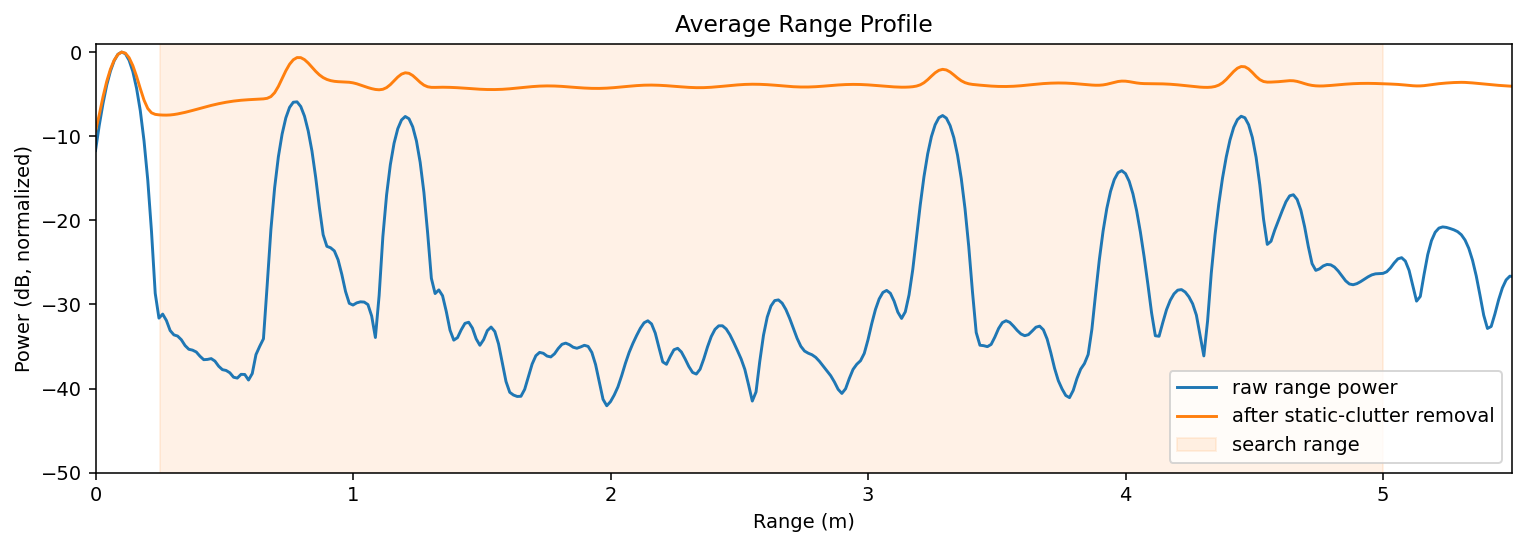

In [131]:
def db_norm(power, floor_db=-50):
    power = np.asarray(power, dtype=np.float64)
    power = np.maximum(power, np.finfo(np.float64).tiny)
    out = 10 * np.log10(power / np.max(power))
    return np.maximum(out, -abs(floor_db))

def to_db(power, ref=None):
    power = np.asarray(power, dtype=np.float64)
    power = np.maximum(power, np.finfo(np.float64).tiny)
    if ref is None:
        ref = np.max(power)
    ref = max(float(ref), np.finfo(np.float64).tiny)
    return 10 * np.log10(power / ref)

range_profile = np.mean(np.abs(range_cube) ** 2, axis=(0, 1, 2, 3))
moving_profile = np.mean(np.abs(moving_range_cube) ** 2, axis=(0, 1, 2, 3))

plt.figure(figsize=(11, 4))
plt.plot(range_axis_m, db_norm(range_profile, DYNAMIC_RANGE_DB), label="raw range power")
plt.plot(range_axis_m, db_norm(moving_profile, DYNAMIC_RANGE_DB), label="after static-clutter removal")
plt.axvspan(SEARCH_RANGE_M[0], SEARCH_RANGE_M[1], color="tab:orange", alpha=0.10, label="search range")
plt.xlim(RANGE_PLOT_XLIM_M[0], min(RANGE_PLOT_XLIM_M[1], range_axis_m[-1]))
plt.ylim(-DYNAMIC_RANGE_DB, 1)
plt.xlabel("Range (m)")
plt.ylabel("Power (dB, normalized)")
plt.title("Average Range Profile")
plt.legend()
plt.tight_layout()
plt.show()

In [132]:
def choose_range_gate(moving_cube, range_axis, search_range_m, target_range_m, half_width_m):
    if target_range_m is None:
        valid = (range_axis >= search_range_m[0]) & (range_axis <= search_range_m[1])
        if not np.any(valid):
            raise ValueError("SEARCH_RANGE_M does not overlap the range axis.")
        power_per_range = np.mean(np.abs(moving_cube) ** 2, axis=(0, 1, 2, 3))
        valid_indices = np.flatnonzero(valid)
        center_idx = valid_indices[np.argmax(power_per_range[valid])]
        center_m = float(range_axis[center_idx])
    else:
        center_m = float(target_range_m)
        center_idx = int(np.argmin(np.abs(range_axis - center_m)))

    gate = np.abs(range_axis - center_m) <= half_width_m
    gate &= range_axis >= 0
    if not np.any(gate):
        gate[center_idx] = True
    return center_m, gate

target_range_m, range_gate = choose_range_gate(
    moving_range_cube,
    range_axis_m,
    SEARCH_RANGE_M,
    TARGET_RANGE_M,
    RANGE_GATE_HALF_WIDTH_M,
)

print(f"Search range dang xet: {SEARCH_RANGE_M[0]:.3f} m -> {SEARCH_RANGE_M[1]:.3f} m")
print(f"Selected target range center: {target_range_m:.3f} m")
print(f"Micro-Doppler range gate: {range_axis_m[range_gate][0]:.3f} m -> {range_axis_m[range_gate][-1]:.3f} m ({range_gate.sum()} bins)")

Search range dang xet: 0.250 m -> 5.000 m
Selected target range center: 0.782 m
Micro-Doppler range gate: 0.435 m -> 1.130 m (49 bins)


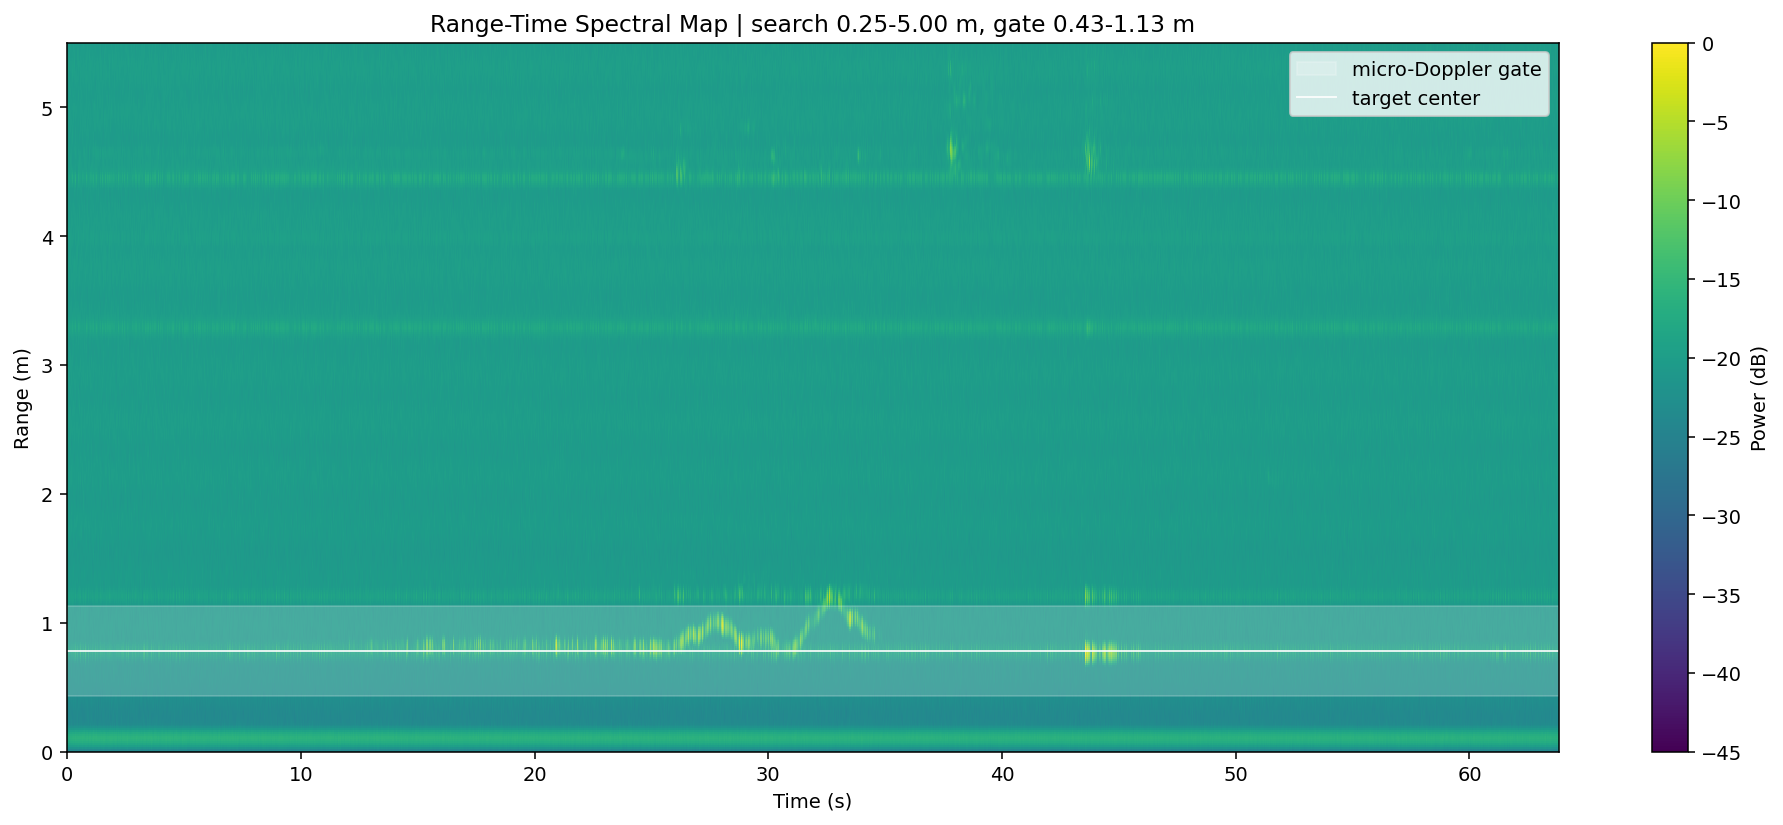

In [133]:
range_time_power = np.mean(np.abs(moving_range_cube) ** 2, axis=(1, 2, 3))
if RANGE_TIME_SCALE_MODE == "db":
    range_time_view = to_db(range_time_power.T)
    range_time_cbar = "Power (dB)"
else:
    range_time_view = range_time_power.T / np.max(range_time_power)
    range_time_cbar = "Normalized Power"

plt.figure(figsize=(14, 6))
plt.pcolormesh(
    time_axis_s,
    range_axis_m,
    range_time_view,
    shading="auto",
    cmap="viridis",
    vmin=RANGE_TIME_VMIN_DB,
    vmax=RANGE_TIME_VMAX_DB,
)
plt.axhspan(range_axis_m[range_gate][0], range_axis_m[range_gate][-1], color="white", alpha=0.18, label="micro-Doppler gate")
plt.axhline(target_range_m, color="white", linewidth=1.0, alpha=0.85, label="target center")
plt.ylim(RANGE_TIME_RANGE_M[0], min(RANGE_TIME_RANGE_M[1], range_axis_m[-1]))
plt.xlabel("Time (s)")
plt.ylabel("Range (m)")
plt.title(
    f"Range-Time Spectral Map | search {SEARCH_RANGE_M[0]:.2f}-{SEARCH_RANGE_M[1]:.2f} m, "
    f"gate {range_axis_m[range_gate][0]:.2f}-{range_axis_m[range_gate][-1]:.2f} m"
)
plt.colorbar(label=range_time_cbar)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

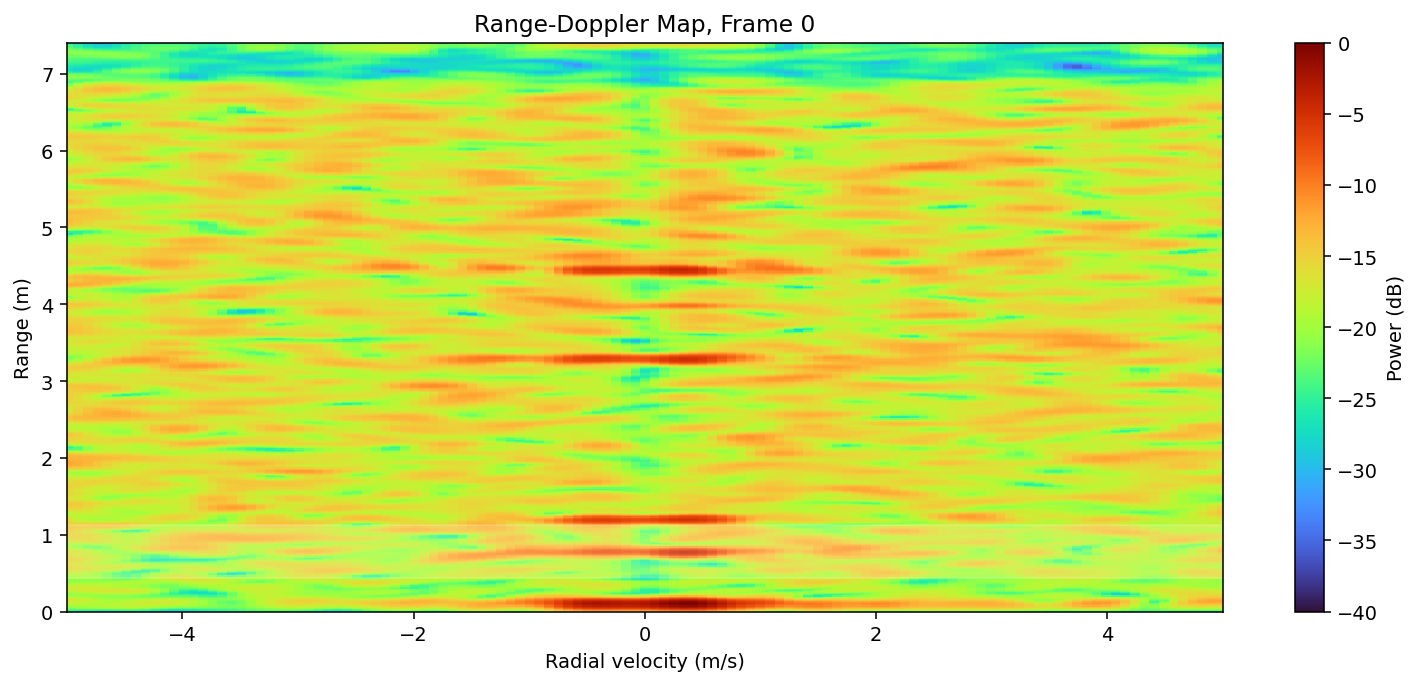

In [134]:
def range_doppler_for_frame(moving_cube, frame_idx, n_doppler_fft):
    frame_idx = int(np.clip(frame_idx, 0, moving_cube.shape[0] - 1))
    x = moving_cube[frame_idx]
    win = np.hanning(x.shape[0]).astype(np.float32)[:, None, None, None]
    rd = np.fft.fftshift(np.fft.fft(x * win, n=n_doppler_fft, axis=0), axes=0)
    power = np.sum(np.abs(rd) ** 2, axis=(1, 2))
    return power.T

rd_map = range_doppler_for_frame(moving_range_cube, EXAMPLE_FRAME, N_DOPPLER_FFT)
rd_map_db = to_db(rd_map)

plt.figure(figsize=(11, 5))
plt.pcolormesh(
    velocity_axis_mps,
    range_axis_m,
    rd_map_db,
    shading="auto",
    cmap="turbo",
    vmin=MICRODOPPLER_VMIN_DB,
    vmax=MICRODOPPLER_VMAX_DB,
)
plt.axhspan(range_axis_m[range_gate][0], range_axis_m[range_gate][-1], color="white", alpha=0.16)
if RANGE_DOPPLER_VEL_LIMIT_MPS is not None:
    plt.xlim(-RANGE_DOPPLER_VEL_LIMIT_MPS, RANGE_DOPPLER_VEL_LIMIT_MPS)
plt.ylim(0, min(8, range_axis_m[-1]))
plt.xlabel("Radial velocity (m/s)")
plt.ylabel("Range (m)")
plt.title(f"Range-Doppler Map, Frame {EXAMPLE_FRAME}")
plt.colorbar(label="Power (dB)")
plt.tight_layout()
plt.show()

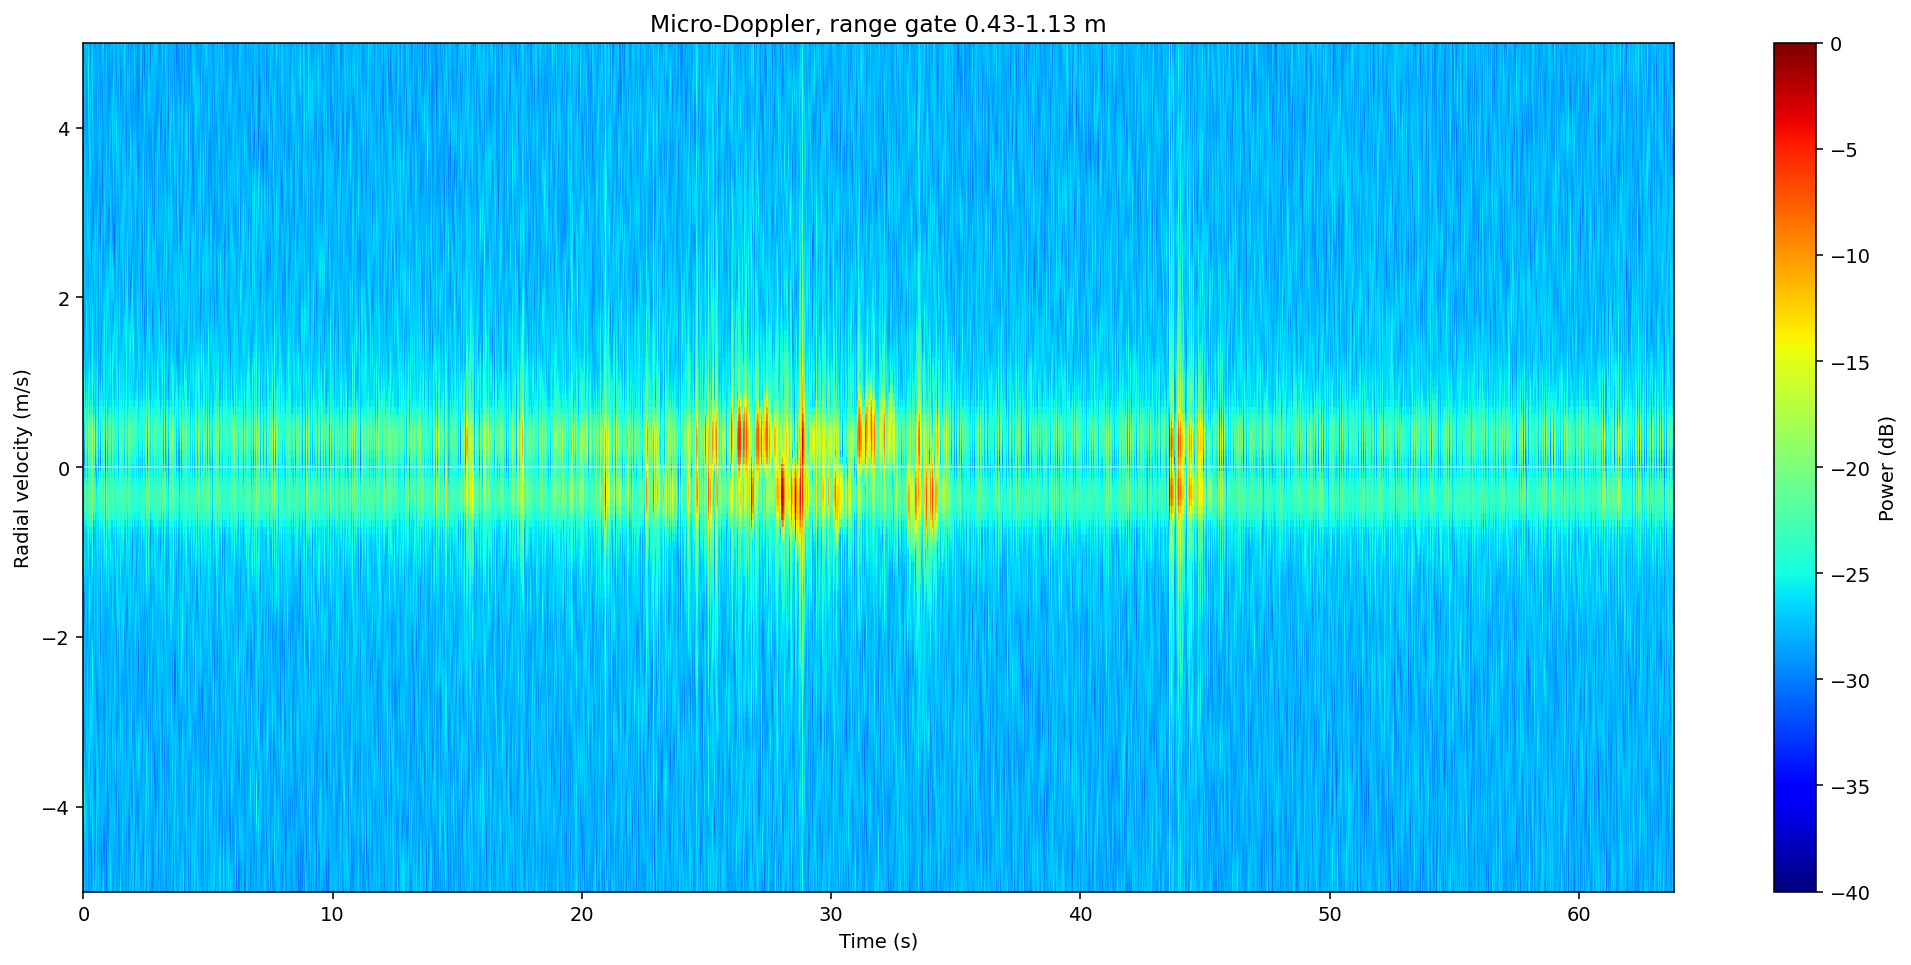

In [135]:
def compute_microdoppler(moving_cube, range_gate, n_doppler_fft):
    # Shape before FFT: frames, loops, chirps_per_loop, rx, selected_range_bins.
    x = moving_cube[..., range_gate]
    win = np.hanning(x.shape[1]).astype(np.float32)[None, :, None, None, None]
    doppler_cube = np.fft.fftshift(np.fft.fft(x * win, n=n_doppler_fft, axis=1), axes=1)
    power = np.sum(np.abs(doppler_cube) ** 2, axis=(2, 3, 4))
    return power

microdoppler_power = compute_microdoppler(moving_range_cube, range_gate, N_DOPPLER_FFT)
microdoppler_db = to_db(microdoppler_power.T)

plt.figure(figsize=MICRODOPPLER_FIGSIZE)
plt.pcolormesh(
    time_axis_s,
    velocity_axis_mps,
    microdoppler_db,
    shading="auto",
    cmap="jet",
    vmin=MICRODOPPLER_VMIN_DB,
    vmax=MICRODOPPLER_VMAX_DB,
)
if MICRODOPPLER_VEL_LIMIT_MPS is not None:
    plt.ylim(-MICRODOPPLER_VEL_LIMIT_MPS, MICRODOPPLER_VEL_LIMIT_MPS)
plt.axhline(0, color="white", linewidth=0.8, alpha=0.55)
plt.xlabel("Time (s)")
plt.ylabel("Radial velocity (m/s)")
plt.title(
    f"Micro-Doppler, range gate {range_axis_m[range_gate][0]:.2f}-{range_axis_m[range_gate][-1]:.2f} m"
)
plt.colorbar(label="Power (dB)")
plt.tight_layout()
plt.show()

## Notes for checking correctness

- If the range profile looks wrong or mirrored, toggle `Q_FIRST` in the first code cell and rerun.
- `N_RANGE_FFT` and `N_DOPPLER_FFT` can be increased for smoother-looking plots. This changes display bin spacing through zero-padding, not the true physical resolution.
- If the target is not selected well, set `TARGET_RANGE_M` manually and reduce/increase `RANGE_GATE_HALF_WIDTH_M`.
- The micro-Doppler plot uses the frame period for the time axis and the same-TX PRI for the velocity axis. This is important because chirps inside a frame are dense, but there is a gap between frames.
- For this config file, `frameCfg ... 20 ...` means 20 ms per frame, i.e. 50 FPS, even though the file name contains `100fps`.